# Market State Vector Example

This notebook reads local daily OHLC data from `data/spx_1d.csv`, takes log prices, builds the full online market state vector, extracts the compact core state vector, plots diagnostics, and runs the built-in evaluation.


In [19]:
import importlib
import random

import numpy as np
import pandas as pd

import cpd
import cpd.market_state_vector as msv

importlib.reload(msv)
importlib.reload(cpd)

from cpd import (
    load_data,
    build_market_state_vector,
    get_core_state_vector,
    evaluate_state_vector,
    plot_price_state_background,
)


In [20]:
def random_month_window(index: pd.DatetimeIndex, months_count: int = 3) -> tuple[pd.Timestamp, pd.Timestamp]:
    months = index.to_period("M").unique()
    if len(months) == 0:
        raise ValueError("Cannot choose a random month from an empty index.")
    if len(months) <= months_count:
        return months[0].start_time, months[-1].end_time
    start_idx = random.randrange(0, len(months) - months_count + 1)
    window_months = months[start_idx : start_idx + months_count]
    return window_months[0].start_time, window_months[-1].end_time


In [21]:
raw_df = load_data(symbol="spx", interval="1d")
if (raw_df <= 0).any().any():
    raise ValueError("OHLC prices must be positive before taking logs.")

df = np.log(raw_df)

print(f"Loaded {len(df)} bars from data/spx_1d.csv")
df.head()


Loaded 4126 bars from data/spx_1d.csv


,Open,High,Low,Close
Date,,,,
2010-01-04,7.018008,7.033392,7.018008,7.032615
2010-01-05,7.032324,7.035823,7.029672,7.035726
2010-01-06,7.035013,7.038073,7.033462,7.036272
2010-01-07,7.035506,7.040939,7.031140,7.040265
2010-01-08,7.039240,7.043500,7.035462,7.043142


In [22]:
state_df = build_market_state_vector(
    data=df,
    detector_method="cusum",
    detector_q=1,
)


In [23]:
core_state_df = get_core_state_vector(state_df)
core_state_df.head()


,current_trend,current_phase,position,regime_volatility,dist_point2_pct,dist_point3_pct
timestamp,,,,,,
2010-01-04,no_trend,no_phase,NaN,0.000000,NaN,NaN
2010-01-05,no_trend,no_phase,NaN,0.000000,NaN,NaN
2010-01-06,no_trend,no_phase,NaN,0.001814,NaN,NaN
2010-01-07,no_trend,no_phase,NaN,0.001791,NaN,NaN
2010-01-08,no_trend,no_phase,NaN,0.001472,NaN,NaN


In [24]:
plot_start, plot_end = random_month_window(state_df.index, months_count=6)
print(f"Plotting diagnostic charts for {plot_start:%Y-%m} to {plot_end:%Y-%m}")


Plotting diagnostic charts for 2020-08 to 2021-01


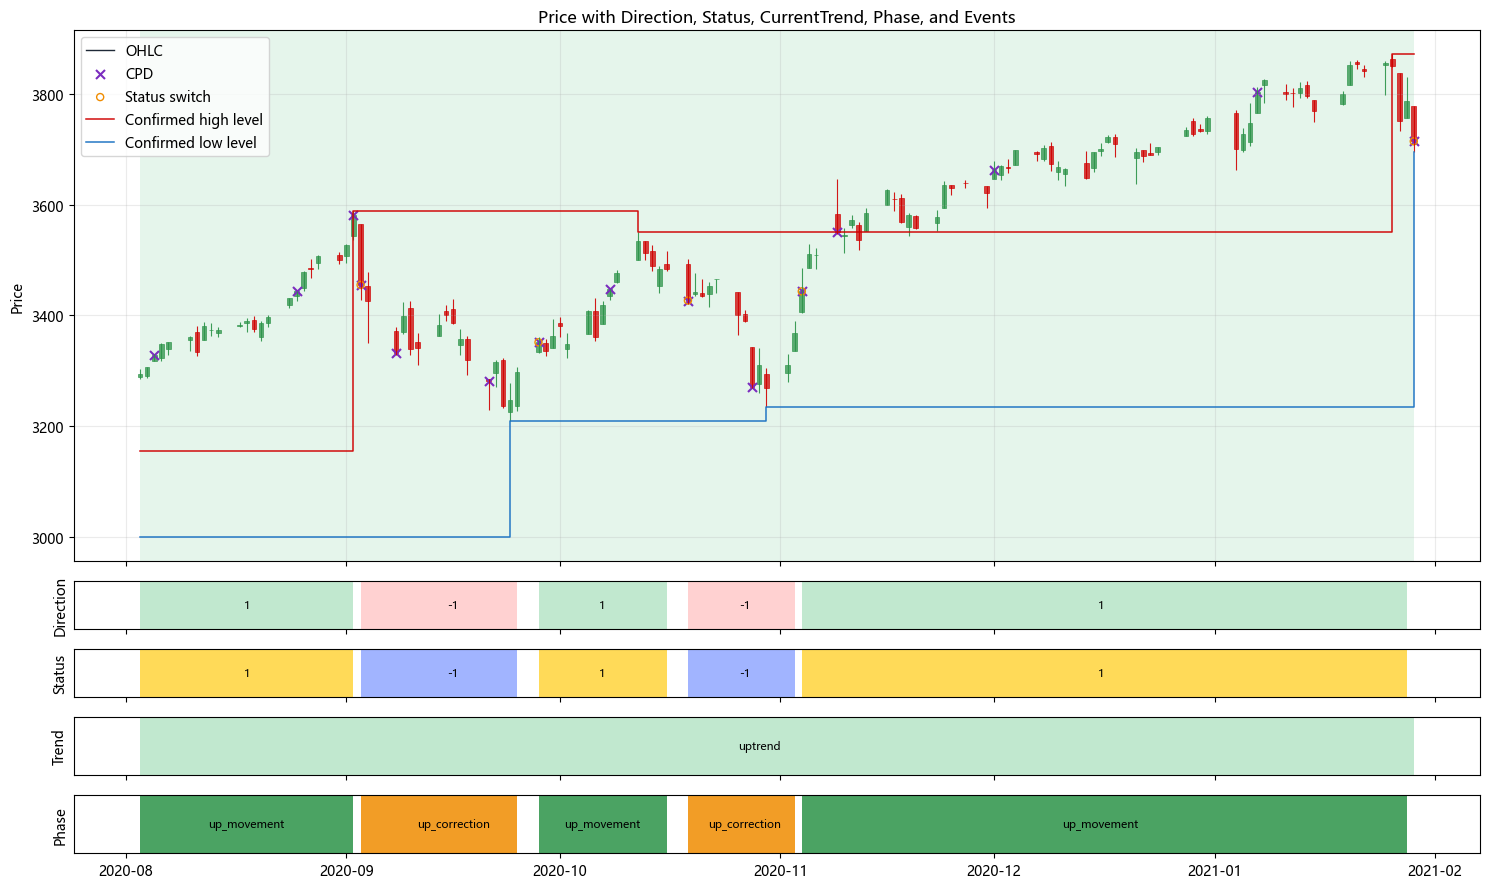

In [25]:
plot_price_state_background(
    state_df,
    price_is_log=True,
    start=plot_start,
    end=plot_end,
);


In [26]:
evaluation = evaluate_state_vector(
    state_df,
    price_is_log=True,
)

evaluation["state_duration_summary"]


,count,mean,median,min,max
current_trend,,,,,
downtrend,11,43.181818,29.0,3,128
downtrend_question,13,3.923077,3.0,1,11
no_trend,17,42.058824,22.0,4,130
uptrend,11,254.545455,170.0,21,697
uptrend_question,15,5.666667,3.0,1,41


## Point2-Point3 Interval

Simple statistics for the bar distance between each unique point2 and point3 pair.


In [27]:
evaluation["point23_interval_summary"]


,count,mean,std,median,min,max
current_trend,,,,,,
downtrend,19,5.894737,3.446330,5.0,1,14
downtrend_question,3,21.333333,25.696952,7.0,6,51
uptrend,40,11.000000,10.185460,8.0,1,58
uptrend_question,5,7.600000,5.128353,8.0,2,14


## Trend Quality: Dynamic and Life-Time

Following the 1-2-3 trend indicator study, `trend_dynamic` measures the extension from point3 toward the newest point2-like extreme relative to the original `point2 - point3` distance. `trend_lifetime_movements` counts how many direction-aligned movements the active trend has survived.

In [28]:
evaluation["trend_quality_summary"]

trend_dynamic                                          \
                      count      mean    median       min       max   
current_trend                                                         
downtrend               475  2.167153  1.959302  1.003108  3.593443   
uptrend                2800  2.172750  1.968196  1.002415  6.241290   

              trend_lifetime_movements                             \
                                 count      mean median  min  max   
current_trend                                                       
downtrend                          475  2.783158    2.0  2.0  5.0   
uptrend                           2800  2.205357    2.0  2.0  5.0   

              trend_lifetime_bars_since_point3                                
                                         count       mean median  min    max  
current_trend                                                                 
downtrend                                  475  34.267368   27.0  1.0  105.0  
uptrend                                   2800  74.862500   55.0  1.0  336.0

In [29]:
evaluation["trend_quality_terminal"].tail()

,current_trend,start,end,bars,terminal_dynamic,terminal_lifetime_movements,terminal_lifetime_bars_since_point3
17,downtrend,2022-09-16,2022-10-21,26,1.433839,2.0,12.0
18,uptrend,2022-11-10,2022-12-14,24,1.002415,2.0,6.0
19,uptrend,2023-05-18,2025-03-03,448,1.140816,2.0,33.0
20,downtrend,2025-03-31,2025-05-09,29,3.593443,3.0,32.0
21,uptrend,2025-05-13,2025-11-19,133,1.708827,2.0,28.0


In [30]:
evaluation["transition_matrix"]


current_trend,downtrend,downtrend_question,no_trend,uptrend,uptrend_question
current_trend,,,,,
downtrend,0.976842,0.000000,0.014737,0.000000,0.008421
downtrend_question,0.196078,0.745098,0.000000,0.000000,0.058824
no_trend,0.000000,0.009804,0.977591,0.001401,0.011204
uptrend,0.000000,0.000714,0.003214,0.996071,0.000000
uptrend_question,0.011765,0.047059,0.000000,0.117647,0.823529


In [31]:
evaluation["position_future_returns"][5]


,count,mean,std,median,min,max
position,,,,,,
"(-inf, 0.0]",184,0.011244,0.036027,0.011692,-0.140676,0.160395
"(0.0, 0.2]",85,0.005571,0.041139,0.012434,-0.133785,0.098984
"(0.2, 0.4]",193,0.004871,0.034575,0.010652,-0.139421,0.087637
"(0.4, 0.6]",399,0.001680,0.030129,0.005878,-0.162279,0.069374
"(0.6, 0.8]",572,0.002363,0.024820,0.006306,-0.198044,0.058099
"(0.8, 1.0]",508,0.001798,0.018149,0.003969,-0.122062,0.048870
"(1.0, inf]",2151,0.001480,0.016258,0.002991,-0.124364,0.066227


In [32]:
evaluation["trend_future_returns"][5]


,count,mean,std,median,min,max
current_trend,,,,,,
downtrend,475,0.004973,0.035893,0.008153,-0.162279,0.160395
downtrend_question,51,-0.020110,0.044361,-0.019196,-0.198044,0.047336
no_trend,710,0.002289,0.023401,0.004199,-0.132610,0.064671
uptrend,2800,0.002288,0.018200,0.003888,-0.139421,0.070679
uptrend_question,85,0.000924,0.022263,0.005094,-0.077067,0.040749


## Phase Evaluation

Future-return and persistence summaries grouped by `current_phase`.


In [33]:
evaluation["phase_future_returns"][5]


,count,mean,std,median,min,max
current_phase,,,,,,
down_correction,268,0.000278,0.029298,0.006425,-0.162279,0.066227
down_movement,258,0.004891,0.044373,0.006672,-0.198044,0.160395
no_phase,710,0.002289,0.023401,0.004199,-0.132610,0.064671
up_correction,508,0.005333,0.025530,0.008882,-0.139421,0.070679
up_movement,2377,0.001588,0.016318,0.003247,-0.124364,0.056203


In [34]:
evaluation["phase_duration_summary"]


,count,mean,median,min,max
current_phase,,,,,
down_correction,34,7.882353,4.5,1,40
down_movement,38,6.789474,6.0,1,18
no_phase,17,42.058824,22.0,4,130
up_correction,54,9.407407,8.0,1,26
up_movement,63,37.730159,22.0,2,309


In [35]:
evaluation["phase_transition_matrix"]


current_phase,down_correction,down_movement,no_phase,up_correction,up_movement
current_phase,,,,,
down_correction,0.873134,0.089552,0.022388,0.000000,0.014925
down_movement,0.131783,0.852713,0.003876,0.000000,0.011628
no_phase,0.000000,0.009804,0.977591,0.000000,0.012605
up_correction,0.000000,0.001969,0.011811,0.893701,0.092520
up_movement,0.000000,0.002524,0.001262,0.022718,0.973496
